<a href="https://colab.research.google.com/github/Bhavishya-2005/apex-planet-data-analytics--task-2/blob/main/apexplanet_task_3_deep_dive_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_dataset.csv to cleaned_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month,Order_Month_Name,Age_Group
0,ORD100002,25-02-2025,CUST5529,Customer_227,30,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,2025,2,February,18-30
1,ORD100003,14-10-2025,CUST3127,Customer_182,63,Male,Bengaluru,Book,Education,5,27906.16,139530.80,2025,10,October,60+
2,ORD100004,13-05-2025,CUST8887,Customer_487,62,Female,Bengaluru,Book,Education,8,37491.06,299928.48,2025,5,May,60+
3,ORD100005,02-12-2025,CUST2515,Customer_470,65,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,2025,12,December,60+
4,ORD100006,20-11-2025,CUST4796,Customer_380,44,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,2025,11,November,31-45


In [ ]:
df.shape

(1000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   object 
 1   Order_Date        1000 non-null   object 
 2   Customer_ID       1000 non-null   object 
 3   Customer_Name     1000 non-null   object 
 4   Age               1000 non-null   int64  
 5   Gender            1000 non-null   object 
 6   City              1000 non-null   object 
 7   Product           1000 non-null   object 
 8   Category          1000 non-null   object 
 9   Quantity          1000 non-null   int64  
 10  Unit_Price        1000 non-null   float64
 11  Total_Sales       1000 non-null   float64
 12  Order_Year        1000 non-null   int64  
 13  Order_Month       1000 non-null   int64  
 14  Order_Month_Name  1000 non-null   object 
 15  Age_Group         1000 non-null   object 
dtypes: float64(2), int64(4), object(10)
memory 

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,0
Gender,0
City,0
Product,0
Category,0
Quantity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales,Order_Year,Order_Month
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.353000,5.435000,25486.783410,139399.439650,2025.005000,6.518000
std,13.683626,2.838632,14179.402361,114100.051546,0.070569,3.498845
min,18.000000,1.000000,145.780000,437.340000,2025.000000,1.000000
25%,30.000000,3.000000,13895.722500,47066.632500,2025.000000,3.000000
50%,41.000000,5.000000,25398.740000,108594.025000,2025.000000,6.000000
75%,53.000000,8.000000,37512.382500,203722.882500,2025.000000,10.000000
max,65.000000,10.000000,49997.530000,493677.500000,2026.000000,12.000000


In [ ]:
print("Products:")
print(df["Product"].unique())

print("\nCategories:")
print(df["Category"].unique())

print("\nCities:")
print(df["City"].unique())

print("\nGender:")
print(df["Gender"].unique())

print("\nAge Groups:")
print(df["Age_Group"].unique())

Products:
['Rice' 'Book' 'Mobile' 'Laptop' 'Shoes' 'Chair']

Categories:
['Grocery' 'Education' 'Electronics' 'Fashion' 'Furniture']

Cities:
['Bengaluru' 'Kolkata' 'Hyderabad' 'Patna' 'Mumbai' 'Delhi' 'Gaya' 'Pune']

Gender:
['Female' 'Male']

Age Groups:
['18-30' '60+' '31-45' '46-60' 'Under 18']


In [ ]:
print("Total Customers:", df["Customer_ID"].nunique())
print("Total Orders:", df["Order_ID"].nunique())
print("Total Products:", df["Product"].nunique())
print("Total Categories:", df["Category"].nunique())
print("Total Cities:", df["City"].nunique())

Total Customers: 947
Total Orders: 992
Total Products: 6
Total Categories: 5
Total Cities: 8


In [ ]:
print("Total Sales:", df["Total_Sales"].sum())
print("Total Quantity Sold:", df["Quantity"].sum())
print("Average Sales per Row:", df["Total_Sales"].mean())

Total Sales: 139399439.65
Total Quantity Sold: 5435
Average Sales per Row: 139399.43965000001


In [ ]:
total_sales = df["Total_Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 139399439.65


In [ ]:
total_orders = df["Order_ID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 992


In [ ]:
total_customers = df["Customer_ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 947


In [ ]:
average_order_value = total_sales / total_orders

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 140523.63


In [ ]:
customer_orders = df.groupby("Customer_ID")["Order_ID"].nunique()

repeat_customers = (customer_orders > 1).sum()

repeat_customer_rate = (repeat_customers / total_customers) * 100

print("Repeat Customers:", repeat_customers)
print("Repeat Customer Rate:", round(repeat_customer_rate, 2), "%")

Repeat Customers: 52
Repeat Customer Rate: 5.49 %


In [ ]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Repeat Customer Rate"
    ],
    "Value": [
        total_sales,
        total_orders,
        total_customers,
        average_order_value,
        repeat_customer_rate
    ]
})

kpi_summary

,KPI,Value
0,Total Sales,1.393994e+08
1,Total Orders,9.920000e+02
2,Total Customers,9.470000e+02
3,Average Order Value,1.405236e+05
4,Repeat Customer Rate,5.491024e+00


In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print(df["Order_Date"].min())
print(df["Order_Date"].max())

2025-01-01 00:00:00
2026-01-01 00:00:00


/tmp/ipykernel_1122/102097247.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"])


In [ ]:
reference_date = df["Order_Date"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2026-01-02 00:00:00


In [ ]:
rfm = df.groupby("Customer_ID").agg({
    "Order_Date": lambda x: (reference_date - x.max()).days,
    "Order_ID": "nunique",
    "Total_Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST1004,312,1,8321.54
CUST1017,261,1,264230.68
CUST1026,95,1,164965.29
CUST1032,249,1,146990.90
CUST1038,241,1,37068.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,947.000000,947.000000,947.000000
mean,178.779303,1.055966,147201.097835
std,106.493709,0.234529,124507.242841
min,1.000000,1.000000,437.340000
25%,82.500000,1.000000,47859.020000
50%,180.000000,1.000000,112029.570000
75%,272.500000,1.000000,214435.455000
max,366.000000,3.000000,867333.240000


In [ ]:
rfm.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0


In [ ]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer_ID,,,,,,
CUST1004,312,1,8321.54,1,1,1
CUST1017,261,1,264230.68,2,1,5
CUST1026,95,1,164965.29,4,1,4
CUST1032,249,1,146990.90,2,1,4
CUST1038,241,1,37068.40,2,1,1


In [ ]:
rfm["R_Score"] = rfm["R_Score"].astype(int)
rfm["F_Score"] = rfm["F_Score"].astype(int)
rfm["M_Score"] = rfm["M_Score"].astype(int)

In [ ]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
Customer_ID,,,,,,,
CUST1004,312,1,8321.54,1,1,1,3
CUST1017,261,1,264230.68,2,1,5,8
CUST1026,95,1,164965.29,4,1,4,9
CUST1032,249,1,146990.90,2,1,4,7
CUST1038,241,1,37068.40,2,1,1,4


In [ ]:
def segment_customer(score):
    if score >= 12:
        return "High Value"
    elif score >= 8:
        return "Medium Value"
    else:
        return "Low Value"

rfm["Segment"] = rfm["RFM_Score"].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
Customer_ID,,,,,,,,
CUST1004,312,1,8321.54,1,1,1,3,Low Value
CUST1017,261,1,264230.68,2,1,5,8,Medium Value
CUST1026,95,1,164965.29,4,1,4,9,Medium Value
CUST1032,249,1,146990.90,2,1,4,7,Low Value
CUST1038,241,1,37068.40,2,1,1,4,Low Value


In [ ]:
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

Segment
Medium Value    506
Low Value       267
High Value      174
Name: count, dtype: int64


In [ ]:
segment_sales = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

print(segment_sales)

Segment
Medium Value    75527889.58
High Value      46142939.51
Low Value       17728610.56
Name: Monetary, dtype: float64


In [ ]:
segment_avg = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

print(segment_avg)

Segment
High Value      265189.307529
Medium Value    149264.603913
Low Value        66399.290487
Name: Monetary, dtype: float64


In [ ]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("Segment", "count"),
    Total_Sales=("Monetary", "sum"),
    Average_Spending=("Monetary", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Recency=("Recency", "mean")
).reset_index()

segment_summary

,Segment,Customers,Total_Sales,Average_Spending,Average_Frequency,Average_Recency
0,High Value,174,46142939.51,265189.307529,1.264368,82.798851
1,Low Value,267,17728610.56,66399.290487,1.000000,254.254682
2,Medium Value,506,75527889.58,149264.603913,1.013834,171.958498


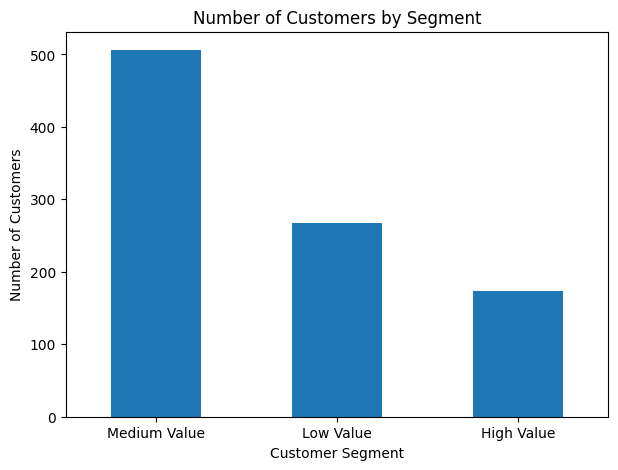

In [ ]:
import matplotlib.pyplot as plt

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(7, 5))
segment_counts.plot(kind="bar")
plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

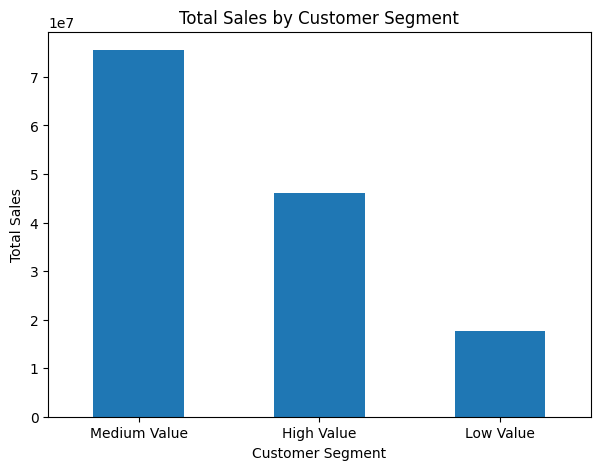

In [ ]:
segment_sales = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
segment_sales.plot(kind="bar")
plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

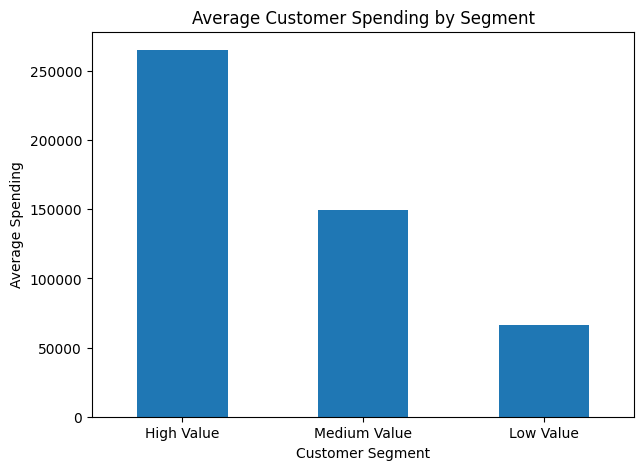

In [ ]:
segment_avg = rfm.groupby("Segment")["Monetary"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
segment_avg.plot(kind="bar")
plt.title("Average Customer Spending by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Spending")
plt.xticks(rotation=0)
plt.show()

In [ ]:
category_sales = df.groupby("Category")["Total_Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Electronics    50778581.70
Education      25031689.40
Grocery        22231711.28
Furniture      21521561.48
Fashion        19835895.79
Name: Total_Sales, dtype: float64


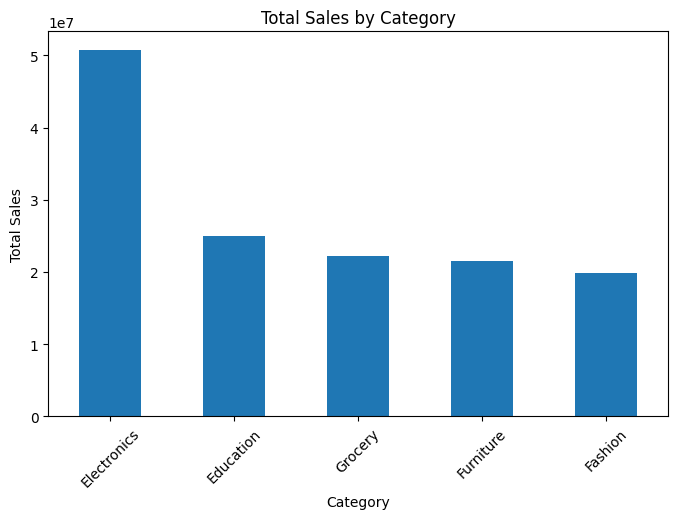

In [ ]:
plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
city_sales = df.groupby("City")["Total_Sales"].sum().sort_values(ascending=False)

print(city_sales)

City
Patna        20826584.43
Kolkata      18884349.57
Bengaluru    18773574.32
Mumbai       18757050.17
Hyderabad    17166766.87
Delhi        16097079.00
Pune         14513175.90
Gaya         14380859.39
Name: Total_Sales, dtype: float64


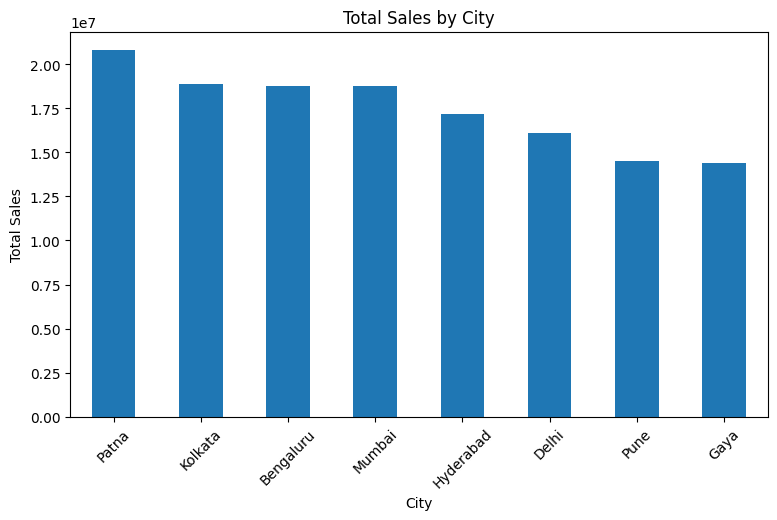

In [ ]:
plt.figure(figsize=(9, 5))
city_sales.plot(kind="bar")
plt.title("Total Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [ ]:
monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Total_Sales"].sum()

monthly_sales.index = monthly_sales.index.astype(str)

print(monthly_sales)

Order_Date
2025-01    10096190.73
2025-02    11511181.46
2025-03    13059899.94
2025-04    12222700.17
2025-05    10984689.25
2025-06    12912332.64
2025-07    11746226.80
2025-08     9448471.22
2025-09     9179896.29
2025-10    12500936.50
2025-11    12627620.22
2025-12    12299904.44
2026-01      809389.99
Name: Total_Sales, dtype: float64


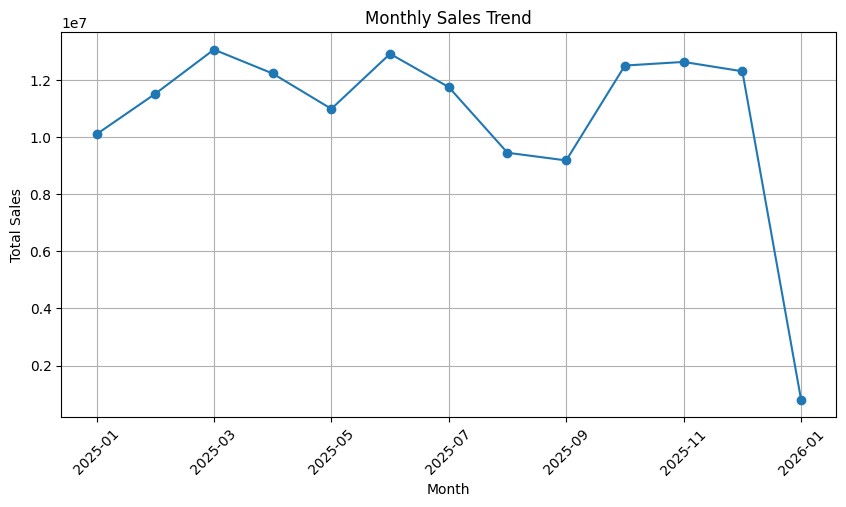

In [ ]:
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
product_sales = df.groupby("Product")["Total_Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product
Laptop    25443008.51
Mobile    25335573.19
Book      25031689.40
Rice      22231711.28
Chair     21521561.48
Shoes     19835895.79
Name: Total_Sales, dtype: float64


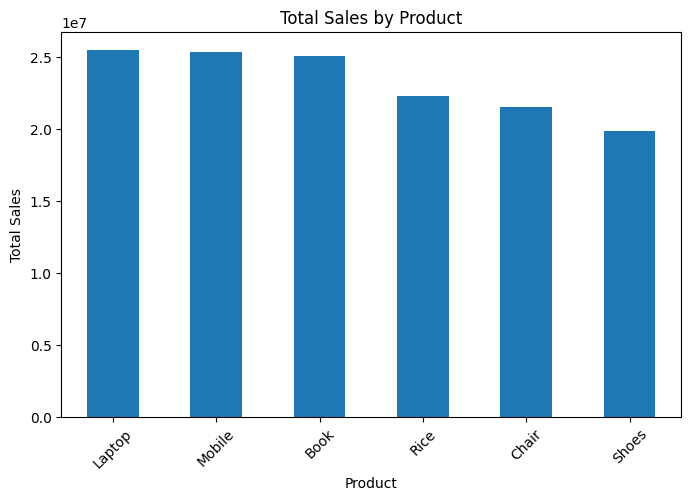

In [ ]:
plt.figure(figsize=(8, 5))
product_sales.plot(kind="bar")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [ ]:
best_segment = segment_summary.loc[segment_summary["Total_Sales"].idxmax()]

print("Highest Revenue Segment:", best_segment["Segment"])
print("Total Sales:", best_segment["Total_Sales"])
print("Customers:", best_segment["Customers"])

Highest Revenue Segment: Medium Value
Total Sales: 75527889.58
Customers: 506


In [ ]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

print("Top Category:", best_category)
print("Sales:", best_category_sales)

Top Category: Electronics
Sales: 50778581.7


In [ ]:
best_city = city_sales.idxmax()
best_city_sales = city_sales.max()

print("Top City:", best_city)
print("Sales:", best_city_sales)

Top City: Patna
Sales: 20826584.43


In [ ]:
best_product = product_sales.idxmax()
best_product_sales = product_sales.max()

print("Top Product:", best_product)
print("Sales:", best_product_sales)

Top Product: Laptop
Sales: 25443008.51


In [ ]:
best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()

print("Highest Sales Month:", best_month)
print("Sales:", best_month_sales)

Highest Sales Month: 2025-03
Sales: 13059899.94


In [ ]:
insights = pd.DataFrame({
    "Analysis": [
        "Highest Revenue Customer Segment",
        "Top Sales Category",
        "Top Sales City",
        "Top Sales Product",
        "Highest Sales Month"
    ],
    "Result": [
        best_segment["Segment"],
        best_category,
        best_city,
        best_product,
        best_month
    ]
})

insights

,Analysis,Result
0,Highest Revenue Customer Segment,Medium Value
1,Top Sales Category,Electronics
2,Top Sales City,Patna
3,Top Sales Product,Laptop
4,Highest Sales Month,2025-03


In [ ]:
total_segment_sales = rfm["Monetary"].sum()

segment_summary["Sales_Contribution_%"] = (
    segment_summary["Total_Sales"] /
    total_segment_sales * 100
)

segment_summary

,Segment,Customers,Total_Sales,Average_Spending,Average_Frequency,Average_Recency,Sales_Contribution_%
0,High Value,174,46142939.51,265189.307529,1.264368,82.798851,33.101237
1,Low Value,267,17728610.56,66399.290487,1.000000,254.254682,12.717849
2,Medium Value,506,75527889.58,149264.603913,1.013834,171.958498,54.180913


In [ ]:
final_segment_analysis = segment_summary[[
    "Segment",
    "Customers",
    "Total_Sales",
    "Sales_Contribution_%",
    "Average_Spending",
    "Average_Frequency",
    "Average_Recency"
]]

final_segment_analysis

,Segment,Customers,Total_Sales,Sales_Contribution_%,Average_Spending,Average_Frequency,Average_Recency
0,High Value,174,46142939.51,33.101237,265189.307529,1.264368,82.798851
1,Low Value,267,17728610.56,12.717849,66399.290487,1.000000,254.254682
2,Medium Value,506,75527889.58,54.180913,149264.603913,1.013834,171.958498


In [ ]:
print("========== TASK 3 KEY FINDINGS ==========")

print("\n1. Highest Revenue Customer Segment:")
print(best_segment["Segment"])

print("\n2. Top Sales Category:")
print(best_category)

print("\n3. Top Sales City:")
print(best_city)

print("\n4. Top Sales Product:")
print(best_product)

print("\n5. Highest Sales Month:")
print(best_month)

print("\n6. Repeat Customer Rate:")
print(round(repeat_customer_rate, 2), "%")

print("\n========== SEGMENT ANALYSIS ==========")
print(final_segment_analysis)

========== TASK 3 KEY FINDINGS ==========

1. Highest Revenue Customer Segment:
Medium Value

2. Top Sales Category:
Electronics

3. Top Sales City:
Patna

4. Top Sales Product:
Laptop

5. Highest Sales Month:
2025-03

6. Repeat Customer Rate:
5.49 %

========== SEGMENT ANALYSIS ==========
        Segment  Customers  Total_Sales  Sales_Contribution_%  \
0    High Value        174  46142939.51             33.101237   
1     Low Value        267  17728610.56             12.717849   
2  Medium Value        506  75527889.58             54.180913   

   Average_Spending  Average_Frequency  Average_Recency  
0     265189.307529           1.264368        82.798851  
1      66399.290487           1.000000       254.254682  
2     149264.603913           1.013834       171.958498  


In [ ]:
rfm.to_csv("customer_segmentation.csv", index=True)

In [ ]:
from google.colab import files

files.download("customer_segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>